In [1]:
!git clone https://github.com/hftuner/clovaai-donut.git /content/hftuner

Cloning into '/content/hftuner'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 65 (delta 28), reused 33 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 2.24 MiB | 19.09 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [2]:
# Import
import torch
from transformers import DonutProcessor, VisionEncoderDecoderConfig
from hftuner.donut import DonutModel
import os
import json
from datasets import load_dataset
from hftuner.donut import DataProcessor

In [3]:
dataset = load_dataset('ridwanFatur98/synth-invoice')

README.md:   0%|          | 0.00/419 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  366MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  368MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 81.4MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/900 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

In [4]:
processor = DonutProcessor.from_pretrained('naver-clova-ix/donut-base')

preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.01M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/71.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/355 [00:00<?, ?B/s]

In [5]:
model = DonutModel.from_pretrained('naver-clova-ix/donut-base')

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  809MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  809MB            

model.safetensors: downloading bytes:           |  0.00B            

# Prepare Processor & Dataset

In [6]:
ignore_id = -100
task_start_token = "<parsing>"
new_special_tokens = []
new_special_tokens.extend([task_start_token])
data_processor = DataProcessor()
json2token = data_processor.json2token

def clean_docs_for_donut(sample):
    gt = json.loads(sample["ground_truth"])
    parsed_text = gt
    text = json2token(parsed_text, update_special_tokens_for_json_key=True) # adds a new token for each key
    return {"text": text}

columns_to_remove = [ c for c in dataset['train'].column_names if c not in ['image', 'ground_truth', 'text']]
data_processor.clear_new_special_tokens()
proc_dataset = dataset.map(clean_docs_for_donut, remove_columns=columns_to_remove)

new_key_tokens = data_processor.get_new_special_tokens()
new_special_tokens = list(set(new_special_tokens + new_key_tokens))

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [7]:
len(new_special_tokens)

41

In [8]:
new_special_tokens

['</s_qty>',
 '</s_bill_to>',
 '</s_account_name>',
 '<s_total>',
 '<s_description>',
 '</s_account_number>',
 '<s_invoice_date>',
 '<s_items>',
 '<s_account_name>',
 '<s_invoice_no>',
 '<s_note>',
 '</s_payment_information>',
 '<s_bill_to>',
 '</s_name>',
 '<s_address>',
 '</s_price>',
 '<parsing>',
 '<s_account_number>',
 '</s_note>',
 '</s_address>',
 '<s_phone>',
 '<s_qty>',
 '</s_subtotal>',
 '</s_city>',
 '<s_from_to>',
 '</s_items>',
 '</s_invoice_no>',
 '</s_bank>',
 '</s_email>',
 '<s_subtotal>',
 '</s_total>',
 '</s_phone>',
 '<s_name>',
 '<s_city>',
 '<s_price>',
 '<s_email>',
 '<s_payment_information>',
 '<s_bank>',
 '</s_from_to>',
 '</s_invoice_date>',
 '</s_description>']

In [9]:
def add_token_count(example):
  example['tokens_count'] = processor.tokenizer(
      example['text'],
      add_special_tokens=True,
      return_tensors="pt",
  ).input_ids[0].shape[0]
  return example

In [10]:
processor.tokenizer.add_special_tokens({"additional_special_tokens": new_special_tokens})
multiplier = 64
if len(processor.tokenizer) % multiplier != 0:
  extra_token_count = multiplier - (len(processor.tokenizer) % multiplier)
  print(f"Adding {extra_token_count} fake tokens")
  fake_tokens = [f"<reserved_{i+1}>" for i in range(extra_token_count)]
  processor.tokenizer.add_tokens(fake_tokens)
proc_dataset = proc_dataset.map(add_token_count)

Adding 34 fake tokens


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [11]:
len(processor.tokenizer)

57600

In [12]:
max_length = 300
processor_image_size = [720, 960] # (width, height)
processor.image_processor.size['width'] = processor_image_size[0]
processor.image_processor.size['height'] = processor_image_size[1]
processor.image_processor.do_align_long_axis = False # don't rotate image if height is greater than width

In [13]:
def prepare_data(examples):
    images = [e['image'].convert("RGB") for e in examples]
    texts = [e['text'] for e in examples]
    # create tensor from image
    pixel_values = processor(
        images,
        return_tensors="pt"
        ).pixel_values
    # tokenize text
    input_ids = processor.tokenizer(
        texts,
        add_special_tokens=True, # add <s> and </s>
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).input_ids
    labels = input_ids.clone()
    # ignore pad tokens when calculating `loss`
    labels[labels == processor.tokenizer.pad_token_id] = ignore_id
    return {"pixel_values": pixel_values, "labels": labels}

In [14]:
batch= prepare_data([
    proc_dataset['train'][5],
])
batch.keys(), batch['pixel_values'].shape, batch['labels'].shape

(dict_keys(['pixel_values', 'labels']),
 torch.Size([1, 3, 960, 720]),
 torch.Size([1, 300]))

# Check Dataset

In [15]:
proc_dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth', 'text', 'tokens_count'],
        num_rows: 900
    })
    test: Dataset({
        features: ['image', 'ground_truth', 'text', 'tokens_count'],
        num_rows: 100
    })
})

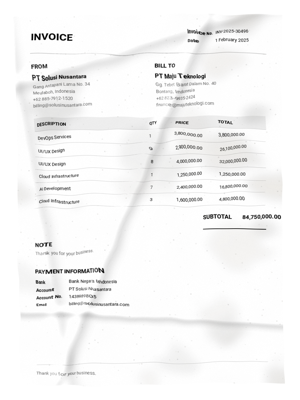

In [16]:
proc_dataset['train'][0]['image'].resize((300,400))

In [17]:
proc_dataset['train'][0]['ground_truth']

'{"bill_to": {"name": "PT Maju Teknologi", "address": "Gg. Tebet Barat Dalam No. 40", "city": "Bontang, Indonesia", "phone": "+62 823-9935-2424", "email": "finance@majuteknologi.com"}, "invoice_date": "1 February 2025", "invoice_no": "INV-2025-30496", "from_to": {"name": "PT Solusi Nusantara", "address": "Gang Antapani Lama No. 34", "city": "Meulaboh, Indonesia", "phone": "+62 885-7912-1520", "email": "billing@solusinusantara.com"}, "items": [{"description": "DevOps Services", "qty": 1, "price": 3800000, "total": 3800000}, {"description": "UI/UX Design", "qty": 9, "price": 2900000, "total": 26100000}, {"description": "UI/UX Design", "qty": 8, "price": 4000000, "total": 32000000}, {"description": "Cloud Infrastructure", "qty": 1, "price": 1250000, "total": 1250000}, {"description": "AI Development", "qty": 7, "price": 2400000, "total": 16800000}, {"description": "Cloud Infrastructure", "qty": 3, "price": 1600000, "total": 4800000}], "subtotal": 84750000, "note": "Thank you for your busi

In [18]:
proc_dataset['train'][0]['text']

'<s_subtotal>84750000</s_subtotal><s_payment_information><s_email>billing@solusinusantara.com</s_email><s_bank>Bank Negara Indonesia</s_bank><s_account_number>1438989805</s_account_number><s_account_name>PT Solusi Nusantara</s_account_name></s_payment_information><s_note>Thank you for your business.</s_note><s_items><s_total>3800000</s_total><s_qty>1</s_qty><s_price>3800000</s_price><s_description>DevOps Services</s_description><sep/><s_total>26100000</s_total><s_qty>9</s_qty><s_price>2900000</s_price><s_description>UI/UX Design</s_description><sep/><s_total>32000000</s_total><s_qty>8</s_qty><s_price>4000000</s_price><s_description>UI/UX Design</s_description><sep/><s_total>1250000</s_total><s_qty>1</s_qty><s_price>1250000</s_price><s_description>Cloud Infrastructure</s_description><sep/><s_total>16800000</s_total><s_qty>7</s_qty><s_price>2400000</s_price><s_description>AI Development</s_description><sep/><s_total>4800000</s_total><s_qty>3</s_qty><s_price>1600000</s_price><s_descriptio

In [19]:
proc_dataset['train'][0]['tokens_count']

272

In [75]:
processor.tokenizer(proc_dataset['train'][0]['text'])

{'input_ids': [0, 57554, 11689, 48845, 35264, 57547, 57561, 57560, 25386, 23291, 56981, 46993, 46192, 41052, 53166, 39539, 34874, 57553, 57562, 42765, 23321, 38834, 57552, 57542, 46680, 2559, 17505, 42438, 50934, 57530, 57533, 24452, 51815, 16388, 10362, 46192, 53166, 57527, 57536, 57535, 34109, 39446, 57245, 55828, 52357, 39539, 57543, 57532, 57528, 51962, 35264, 57555, 57546, 1314, 57525, 57559, 51962, 35264, 57540, 57529, 39647, 39228, 46192, 39748, 57565, 57522, 57528, 9304, 56548, 35264, 57555, 57546, 42378, 57525, 57559, 3822, 43112, 35264, 57540, 57529, 42990, 37152, 47106, 49704, 4360, 57565, 57522, 57528, 9066, 9345, 56239, 57555, 57546, 38873, 57525, 57559, 39832, 35264, 57540, 57529, 42990, 37152, 47106, 49704, 4360, 57565, 57522, 57528, 13519, 35264, 57555, 57546, 1314, 57525, 57559, 13519, 35264, 57540, 57529, 42425, 53182, 38364, 37376, 57565, 57522, 57528, 46519, 657, 56239, 57555, 57546, 38100, 57525, 57559, 35889, 35264, 57540, 57529, 39107, 44707, 57565, 57522, 57528,

In [78]:
len(processor.tokenizer(proc_dataset['train'][0]['text']))

2

In [80]:
len(processor.tokenizer(proc_dataset['train'][0]['text'])['input_ids'])

272

In [81]:
print(proc_dataset['train'][0]['text'])

<s_subtotal>84750000</s_subtotal><s_payment_information><s_email>billing@solusinusantara.com</s_email><s_bank>Bank Negara Indonesia</s_bank><s_account_number>1438989805</s_account_number><s_account_name>PT Solusi Nusantara</s_account_name></s_payment_information><s_note>Thank you for your business.</s_note><s_items><s_total>3800000</s_total><s_qty>1</s_qty><s_price>3800000</s_price><s_description>DevOps Services</s_description><sep/><s_total>26100000</s_total><s_qty>9</s_qty><s_price>2900000</s_price><s_description>UI/UX Design</s_description><sep/><s_total>32000000</s_total><s_qty>8</s_qty><s_price>4000000</s_price><s_description>UI/UX Design</s_description><sep/><s_total>1250000</s_total><s_qty>1</s_qty><s_price>1250000</s_price><s_description>Cloud Infrastructure</s_description><sep/><s_total>16800000</s_total><s_qty>7</s_qty><s_price>2400000</s_price><s_description>AI Development</s_description><sep/><s_total>4800000</s_total><s_qty>3</s_qty><s_price>1600000</s_price><s_description

# Prepare Model

In [20]:
model.config.decoder.max_length = max_length
model.config.pad_token_id = processor.tokenizer.pad_token_id
task_token_id = processor.tokenizer.encode(task_start_token, add_special_tokens=False)[0]
new_emb = model.decoder.resize_token_embeddings(len(processor.tokenizer))
model.config.encoder.image_size = processor_image_size[::-1] # (height, width)
model.config.decoder_start_token_id = task_token_id

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


# Train

In [21]:
save_model_name = "invoice-doc-to-text"

In [108]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

# Arguments for training
training_args = Seq2SeqTrainingArguments(
    output_dir=save_model_name,
    num_train_epochs=20,
    # max_steps = 100,
    max_steps=-1,

    learning_rate=2e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size =1,
    weight_decay=0.01,

    fp16=True,
    logging_steps=100,

    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=1,

    # group_by_length=True,
    predict_with_generate=True,

    # push to hub parameters
    report_to="tensorboard",

    push_to_hub=False,
    # hub_strategy="every_save",
    # hub_model_id=save_model_name,

    remove_unused_columns=False
)

In [109]:
# Create Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    data_collator=prepare_data,
    train_dataset=proc_dataset["train"],
    eval_dataset=proc_dataset["test"],
)

In [110]:
# Start training
trainer.train()

Step,Training Loss
100,0.009279
200,0.014451
300,0.010111
400,0.010025
500,0.010992
600,0.010230
700,0.012266
800,0.013019
900,0.011509
1000,0.007222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Upload Model

In [1]:
from huggingface_hub import login
# login()

In [112]:
from pathlib import Path
from huggingface_hub import HfApi, upload_folder

repo_id = "ridwanFatur98/invoice-doc-to-text"

In [ ]:
save_dir = Path("./upload-to-hf")
save_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [77]:
upload_folder(
    repo_id=repo_id,
    folder_path=str(save_dir),
    repo_type="model",
    commit_message="Upload trained model",
)

CommitInfo(commit_url='https://huggingface.co/ridwanFatur98/invoice-doc-to-text/commit/9f45099fe8f3756374078671acde917d0352d2f5', commit_message='Upload trained model', commit_description='', oid='9f45099fe8f3756374078671acde917d0352d2f5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ridwanFatur98/invoice-doc-to-text', endpoint='https://huggingface.co', repo_type='model', repo_id='ridwanFatur98/invoice-doc-to-text'), pr_revision=None, pr_num=None)

# Inference

In [82]:
import re
import torch
from transformers import DonutProcessor, VisionEncoderDecoderConfig, VisionEncoderDecoderModel

In [83]:
ckpt = "ridwanFatur98/invoice-doc-to-text"

In [84]:
config = VisionEncoderDecoderConfig.from_pretrained(ckpt)

config.json:   0%|          | 0.00/3.43k [00:00<?, ?B/s]

In [85]:
processor = DonutProcessor.from_pretrained(ckpt)

tokenizer_config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.02M [00:00<?, ?B/s]

In [86]:
len(processor.tokenizer)

57600

In [87]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [88]:
# config.dtype = torch.float32

In [89]:
loaded_model = VisionEncoderDecoderModel.from_pretrained(ckpt, config=config, force_download=True)
loaded_model.to(device)
pass

config.json:   0%|          | 0.00/3.43k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  809MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

In [100]:
sample = dataset['train'][0]

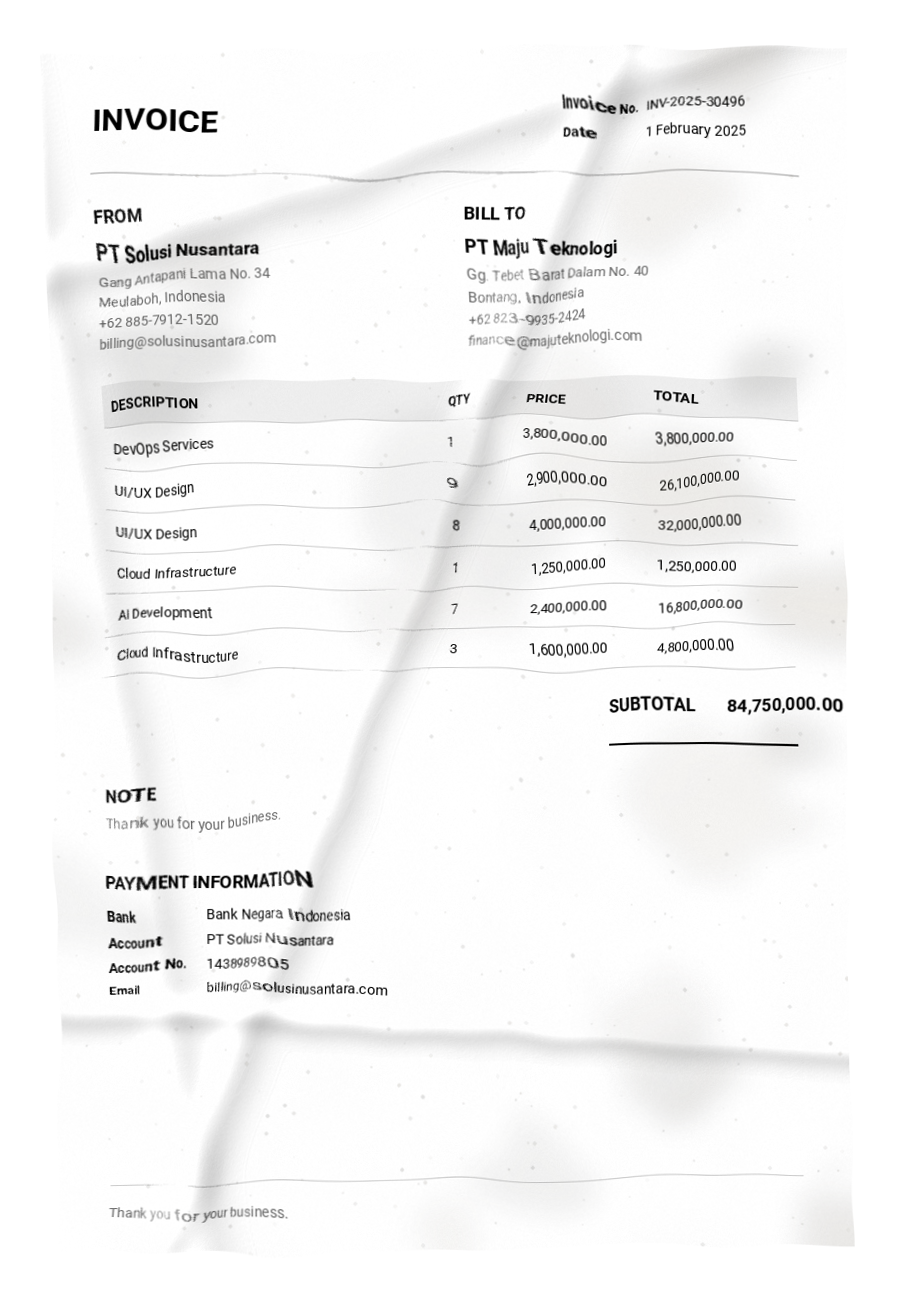

In [101]:
sample['image']

In [102]:
pixel_values = processor(sample['image'],return_tensors="pt").pixel_values.to(device)
# pixel_values = pixel_values.to(torch.float16)

In [103]:
task_start_token = "<parsing>"
decoder_input_ids = processor.tokenizer(task_start_token, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

In [105]:
generated_ids = loaded_model.generate(
    pixel_values,
    decoder_input_ids=decoder_input_ids,
    max_length=300,
    bad_words_ids=[[processor.tokenizer.unk_token_id]]
)

In [106]:
print(f'generated tokens count: {len(generated_ids[0])}')
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

generated tokens count: 273


In [107]:
print(generated_text)
processor.token2json(generated_text)

<parsing><s><s_subtotal> 84750000</s_subtotal><s_payment_information><s_email> billing@solusinusantara.com</s_email><s_bank> Bank Negara Indonesia</s_bank><s_account_number> 1433988905</s_account_number><s_account_name> PT Solusi Nusantara</s_account_name></s_payment_information><s_note> Thank you for your business.</s_note><s_items><s_total> 3800000</s_total><s_qty> 1</s_qty><s_price> 3800000</s_price><s_description> DevOps Services</s_description><sep/><s_total> 26100000</s_total><s_qty> 9</s_qty><s_price> 2900000</s_price><s_description> UI/UX Design</s_description><sep/><s_total> 32000000</s_total><s_qty> 8</s_qty><s_price> 4000000</s_price><s_description> UI/UX Design</s_description><sep/><s_total> 1250000</s_total><s_qty> 1</s_qty><s_price> 1250000</s_price><s_description> Cloud Infrastructure</s_description><sep/><s_total> 16800000</s_total><s_qty> 7</s_qty><s_price> 2400000</s_price><s_description> AI Development</s_description><sep/><s_total> 4800000</s_total><s_qty> 3</s_qty>

{'subtotal': '84750000',
 'payment_information': {'email': 'billing@solusinusantara.com',
  'bank': 'Bank Negara Indonesia',
  'account_number': '1433988905',
  'account_name': 'PT Solusi Nusantara'},
 'note': 'Thank you for your business.',
 'items': [{'total': '3800000',
   'qty': '1',
   'price': '3800000',
   'description': 'DevOps Services'},
  {'total': '26100000',
   'qty': '9',
   'price': '2900000',
   'description': 'UI/UX Design'},
  {'total': '32000000',
   'qty': '8',
   'price': '4000000',
   'description': 'UI/UX Design'},
  {'total': '1250000',
   'qty': '1',
   'price': '1250000',
   'description': 'Cloud Infrastructure'},
  {'total': '16800000',
   'qty': '7',
   'price': '2400000',
   'description': 'AI Development'},
  {'total': '4800000',
   'qty': '3',
   'price': '1600000',
   'description': 'Cloud Infrastructure'}],
 'invoice_no': 'INV-2025-30496',
 'invoice_date': '1 February 2025',
 'from_to': {'phone': '+62 885-7912-1520',
  'name': 'PT Solusi Nusantara',
  '